# 1. Data Preparation and Future Engineering

## 1.1 Data Import and Initial Structuring

In [1]:
import pandas as pd

df = pd.read_csv("luxury_survey_raw.csv")
df.head()

,Timestamp,What is your age range?,Gender,Country of residence,Main occupation,Approximate monthly income (after taxes),"Have you interacted (purchase, website, social media) with Gucci, Dior, or Louis Vuitton in the last 12 months?",How often have you purchased products from any of these brands in the last 12 months?,Have you purchased online (website/app) from these brands in the last 12 months?,Which brand attracts you the most currently?,...,"The digital experience (website, app, social media) feels premium and exclusive.","Personalized recommendations (emails, suggestions, tailored content) feel useful to me.","Digital innovation (e.g., AR, virtual experiences, online personalization) increases my interest in these brands.",I feel emotionally connected to at least one of these brands.,These brands make me feel unique or part of an exclusive group.,"I prefer these brands over similar ones, even if they cost more.",I would recommend these brands to friends or family.,What is your intention to purchase again from these brands in the next 12 months?,"If these brands improve their digital presence, my loyalty would increase.",My digital interactions with these brands strengthen my loyalty.
0,2026/02/13 5:18:54 pm CET,18-24,Female,Spain,Student,"<1,500€",No,Never,"No, but I would consider it",Gucci,...,1,3,3,3,3,3,4,4,3,3
1,2026/02/13 5:20:42 pm CET,18-24,Female,Spain,Student,I'm still a student,Yes,Never,No and I would not consider it,None / I switch frequently,...,4,5,5,1,1,1,1,1,1,1
2,2026/02/13 5:22:03 pm CET,18-24,Female,madrid,Student,I'm still a student,No,Never,No and I would not consider it,None / I switch frequently,...,3,3,3,5,5,1,2,1,4,2
3,2026/02/13 5:24:12 pm CET,18-24,Male,Spain,Student,I'm still a student,No,Never,No and I would not consider it,Louis Vuitton,...,2,4,5,2,4,4,5,3,4,4
4,2026/02/13 5:26:19 pm CET,18-24,Female,spain,Student,I'm still a student,Yes,Once,"No, but I would consider it",Dior,...,2,2,2,3,4,2,3,3,4,3


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 25 columns):
 #   Column                                                                                                             Non-Null Count  Dtype 
---  ------                                                                                                             --------------  ----- 
 0   Timestamp                                                                                                          145 non-null    object
 1   What is your age range?                                                                                            145 non-null    object
 2   Gender                                                                                                             145 non-null    object
 3   Country of residence                                                                                               145 non-null    object
 4   Main occupation                 

In [3]:
df.columns = [
    # --- SECTION 1: Demographics ---
    "timestamp",
    "age_range",
    "gender",
    "country",
    "occupation",
    "income",

    # --- SECTION 2: Interaction & Purchase ---
    "interacted_12m",
    "purchase_frequency",
    "online_purchase_behavior",
    "preferred_brand",

    # --- SECTION 3: Digital Engagement ---
    "consume_social_content",
    "actively_interact_content",
    "follow_luxury_influencers",
    "digital_content_excitement",

    # --- SECTION 4: Digital Experience & Personalization ---
    "online_offline_consistency",
    "digital_premium_experience",
    "personalized_recommendations_useful",
    "digital_innovation_interest",

    # --- SECTION 5: Emotional Loyalty ---
    "emotional_connection",
    "brand_exclusivity_feeling",
    "prefer_over_competitors",
    "brand_recommendation",

    # --- SECTION 6: Behavioral & Future Loyalty ---
    "future_purchase_intention",
    "digital_improvement_increases_loyalty",
    "digital_interaction_strengthens_loyalty"
]

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   timestamp                                145 non-null    object
 1   age_range                                145 non-null    object
 2   gender                                   145 non-null    object
 3   country                                  145 non-null    object
 4   occupation                               145 non-null    object
 5   income                                   145 non-null    object
 6   interacted_12m                           145 non-null    object
 7   purchase_frequency                       145 non-null    object
 8   online_purchase_behavior                 145 non-null    object
 9   preferred_brand                          145 non-null    object
 10  consume_social_content                   145 non-null    int64

,timestamp,age_range,gender,country,occupation,income,interacted_12m,purchase_frequency,online_purchase_behavior,preferred_brand,...,digital_premium_experience,personalized_recommendations_useful,digital_innovation_interest,emotional_connection,brand_exclusivity_feeling,prefer_over_competitors,brand_recommendation,future_purchase_intention,digital_improvement_increases_loyalty,digital_interaction_strengthens_loyalty
0,2026/02/13 5:18:54 pm CET,18-24,Female,Spain,Student,"<1,500€",No,Never,"No, but I would consider it",Gucci,...,1,3,3,3,3,3,4,4,3,3
1,2026/02/13 5:20:42 pm CET,18-24,Female,Spain,Student,I'm still a student,Yes,Never,No and I would not consider it,None / I switch frequently,...,4,5,5,1,1,1,1,1,1,1
2,2026/02/13 5:22:03 pm CET,18-24,Female,madrid,Student,I'm still a student,No,Never,No and I would not consider it,None / I switch frequently,...,3,3,3,5,5,1,2,1,4,2
3,2026/02/13 5:24:12 pm CET,18-24,Male,Spain,Student,I'm still a student,No,Never,No and I would not consider it,Louis Vuitton,...,2,4,5,2,4,4,5,3,4,4
4,2026/02/13 5:26:19 pm CET,18-24,Female,spain,Student,I'm still a student,Yes,Once,"No, but I would consider it",Dior,...,2,2,2,3,4,2,3,3,4,3


## 1.2 Sample Filtering and Eligibility Criteria

To ensure analytical relevance, only respondents who reported interaction with Gucci, Dior, or Louis Vuitton in the last 12 months were retained.

In [5]:
df = df[df["interacted_12m"] == "Yes"]

## 1.3 Data Cleaning and Variable Transformation

### 1.3.1 Income Variable Standardization

The income variable presented inconsistencies (e.g., "<1,500€", "I'm still a student", "Prefer not to say"). To allow numerical processing, income brackets were ordinally encoded.
Non-standard answers were treated as missing values (NaN).

In [6]:
income_mapping = {
    "<1,500€": 1,
    "1,500–2,500€": 2,
    "2,501–4,000€": 3,
    "4,001–7,000€": 4,
    "7,000€+": 5
}

df["income_num"] = df["income"].map(income_mapping)

### 1.3.2 Purchase Frequency Encoding

Purchase frequency was converted into an ordinal numerical proxy reflecting behavioral intensity.

In [7]:
purchase_map = {
    "Never": 1,
    "Once": 2,
    "2–4 times": 3,
    "More than 4 times": 4
}

df["purchase_freq_num"] = df["purchase_frequency"].map(purchase_map)

### 1.3.3 Online Purchase Behavior Encoding

Online purchase behavior was converted into an ordinal numerical variable to capture the intensity of digital transactional engagement and consumers’ openness to online luxury purchasing.

In [8]:
online_purchase_map = {
    "Several times": 4,
    "1–2 times": 3,
    "No, but I would consider it": 2,
    "No and I would not consider it": 1
}

df["online_purchase_num"] = df["online_purchase_behavior"].map(online_purchase_map)

### 1.3.4 Country Variable Standardization

Country responses were standardized to ensure consistent capitalization and geographic aggregation. City-level answers (e.g., “Madrid”) were converted into their corresponding country (“Spain”), and inconsistent capitalization (e.g., “spain”, “Uk”) was harmonized.

In [9]:
df["country"] = df["country"].str.strip().str.lower()

In [10]:
country_corrections = {
    "madrid": "spain",
    "irlanda": "ireland",
    "belgiumm": "belgium",
    "eeuu": "usa"
}

df["country"] = df["country"].replace(country_corrections)

In [11]:
df["country"] = df["country"].str.title()

In [12]:
acronyms = {
    "Usa": "USA",
    "Uae": "UAE",
    "Uk": "UK"
}

df["country"] = df["country"].replace(acronyms)

In [13]:
df["country"].value_counts()

,count
country,
Spain,68
UK,10
France,6
UAE,5
USA,4
Jordan,2
Belgium,2
Mexico,2
Japan,1


## 1.4 Construction of Composite Loyalty Indices

To reduce dimensionality and ensure alignment with the theoretical framework of luxury loyalty, composite indices were constructed from Likert-scale items. Rather than treating each survey question as an independent variable, related items were aggregated into multidimensional loyalty constructs.
All Likert-scale variables ranged from 1 (Strongly disagree) to 5 (Strongly agree). Prior to index construction, responses were converted into numeric format to ensure computational consistency.

### 1.4.1 Digital Engagement Index

The Digital Engagement Index captures the extent to which consumers actively consume and interact with luxury brand content across digital channels. It reflects behavioral interaction intensity and emotional stimulation generated by online brand presence.

The index was computed as the mean score of four items:
- Frequency of consuming luxury brand content on social media
- Active interaction (likes, comments, shares, saves)
- Following influencers or accounts related to the brands
- Excitement or interest generated by digital content

In [14]:
digital_engagement_items = [
    "consume_social_content",
    "actively_interact_content",
    "follow_luxury_influencers",
    "digital_content_excitement"
]

df[digital_engagement_items] = df[digital_engagement_items].apply(pd.to_numeric, errors="coerce")

df["digital_engagement_index"] = df[digital_engagement_items].mean(axis=1)

### 1.4.2 Digital Experience Index

The Digital Experience Index measures the perceived quality and exclusivity of the brands’ digital environments. It reflects consistency, premium perception, personalization effectiveness, and innovation appeal.

The index was computed as the mean score of the following items:
- Perceived consistency between online and offline experience
- Perception of premium and exclusive digital experience
- Usefulness of personalized recommendations
- Impact of digital innovation on brand interest

In [15]:
digital_experience_items = [
    "online_offline_consistency",
    "digital_premium_experience",
    "personalized_recommendations_useful",
    "digital_innovation_interest"
]

df[digital_experience_items] = df[digital_experience_items].apply(pd.to_numeric, errors="coerce")

df["digital_experience_index"] = df[digital_experience_items].mean(axis=1)

### 1.4.3 Emotional Loyalty Index

The Emotional Loyalty Index captures attitudinal loyalty dimensions rooted in emotional attachment and psychological preference. It reflects consumers’ emotional connection, perceived exclusivity, willingness to prioritize the brand over competitors, and advocacy intentions.

The index was calculated as the mean score of:
- Emotional connection to the brand
- Feeling of exclusivity or belonging
- Preference over similar brands even at higher prices
- Willingness to recommend the brand

In [16]:
emotional_loyalty_items = [
    "emotional_connection",
    "brand_exclusivity_feeling",
    "prefer_over_competitors",
    "brand_recommendation"
]

df[emotional_loyalty_items] = df[emotional_loyalty_items].apply(pd.to_numeric, errors="coerce")

df["emotional_loyalty_index"] = df[emotional_loyalty_items].mean(axis=1)

### 1.4.4 Behavioral Loyalty Index

The Behavioral Loyalty Index captures forward-looking and action-oriented loyalty intentions. Unlike emotional loyalty, this construct emphasizes future purchase likelihood and the reinforcing role of digital interactions.

The index was computed as the mean of:
- Intention to purchase again in the next 12 months
- Loyalty increase if digital presence improves
- Perceived strengthening of loyalty through digital interactions

In [17]:
behavioral_loyalty_items = [
    "future_purchase_intention",
    "digital_improvement_increases_loyalty",
    "digital_interaction_strengthens_loyalty"
]

df[behavioral_loyalty_items] = df[behavioral_loyalty_items].apply(pd.to_numeric, errors="coerce")

df["behavioral_loyalty_index"] = df[behavioral_loyalty_items].mean(axis=1)

## 1.5 Feature Selection for Clustering

To ensure theory-driven segmentation, only behavioral and psychological variables were included:

In [18]:
features = [
    "digital_engagement_index",
    "digital_experience_index",
    "emotional_loyalty_index",
    "behavioral_loyalty_index",
    "purchase_freq_num",
    "online_purchase_num"
]

Demographic variables (age, country, income) were excluded to prevent purely demographic clustering and maintain focus on loyalty constructs.

## 1.6 Data Normalization

Because K-means is distance-based, features were standardized using z-score normalization.

In [27]:
df[features].describe()

,digital_engagement_index,digital_experience_index,emotional_loyalty_index,behavioral_loyalty_index,purchase_freq_num,online_purchase_num
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,3.601942,3.640777,3.322816,3.258900,2.281553,2.271845
std,1.118273,0.763498,0.964842,0.832263,0.833343,0.597284
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.250000,2.750000,2.666667,2.000000,2.000000
50%,3.750000,3.750000,3.500000,3.333333,2.000000,2.000000
75%,4.500000,4.250000,4.125000,4.000000,3.000000,3.000000
max,5.000000,5.000000,4.750000,5.000000,4.000000,4.000000


In [22]:
from sklearn.preprocessing import StandardScaler

# Select clustering features and remove missing values
X = df[features].dropna()

# Align the original dataframe with the filtered feature matrix
df = df.loc[X.index]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# 2. Consumer segmentation (Clustering Implementation)

## 2.1 Determining the Optimal Number of Clusters

### 2.1.1 Elbow Method

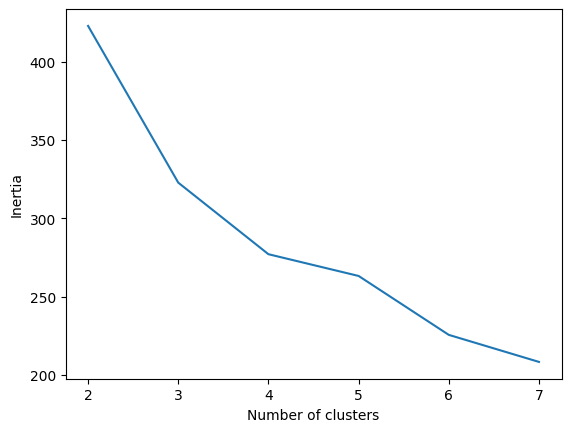

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

The inertia plot shows a substantial decrease from k=2 to k=3 and a smaller reduction from k=3 to k=4. Beyond k=4, the decrease becomes more gradual, indicating diminishing returns from adding additional clusters. This suggests a potential elbow around k=3 (or possibly k=4), although the inflection point is not sharply defined.
Since the elbow is not strongly pronounced, silhouette analysis was used to further validate the optimal number of clusters.

### 2.1.2 Silhouette Score

In [21]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.26059404884724124
k=3, Silhouette Score=0.2657866582569674
k=4, Silhouette Score=0.2281804983727991
k=5, Silhouette Score=0.21735882083731226
k=6, Silhouette Score=0.23499981031975142
k=7, Silhouette Score=0.21656700973824186


The silhouette score reaches its highest value at k = 3 (0.2658), indicating the best balance between intra-cluster cohesion and inter-cluster separation among the tested solutions. For k > 3, the score decreases, suggesting weaker cluster structure and less distinct segmentation. Therefore, k = 3 provides the most statistically robust clustering solution.

## 2.2 Stability Check

This tests whether the 3-cluster solution is robust (not a lucky initialization).

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

seeds = [0, 10, 20, 42, 100, 200]
sil_scores = []

for seed in seeds:
    kmeans = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"Seed={seed} | Silhouette={sil:.4f}")

print(f"\nMean Silhouette: {np.mean(sil_scores):.4f}")
print(f"Std Silhouette:  {np.std(sil_scores):.4f}")

Seed=0 | Silhouette=0.2812
Seed=10 | Silhouette=0.2804
Seed=20 | Silhouette=0.2804
Seed=42 | Silhouette=0.2790
Seed=100 | Silhouette=0.2812
Seed=200 | Silhouette=0.2812

Mean Silhouette: 0.2806
Std Silhouette:  0.0008


The silhouette score remained highly consistent across multiple random initializations (mean = 0.2806, std = 0.0008), confirming the robustness and stability of the three-cluster solution.

## 2.3 Final Model Estimation

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [34]:
# Save final dataset with cluster labels for Results analysis
df.to_csv("luxury_survey_with_clusters.csv", index=False)